In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd

from load import load_comparison
from stats import add_speedup, summary_overall, summary_by_type
from plot import plot_time_scatter, plot_speedup_cdf, plot_median_by_type, plot_speedup_boxplot

## Paths

Apunta a la carpeta con los CSVs de la corrida en godel.
- `bench-xcltj.csv` / `bench-hcltj.csv`: producidos por `bench-query-xcltj` / `bench-query-hcltj`.
- `types.txt`: mapeo `query_id;TYPE{1,2,3}` (en `Queries/`).

In [3]:
RESULTS_DIR = Path("../../results/godel/wikidata-premix-and-fallback-t4000-2026-04-19")
QUERIES_DIR = Path("../../Queries")

xcltj_path = RESULTS_DIR / "bench-xcltj.csv"
hcltj_path = RESULTS_DIR / "bench-hcltj.csv"
types_path = QUERIES_DIR / "types.txt"

## Load

In [4]:
df = load_comparison(xcltj_path, hcltj_path, types_path)
df = add_speedup(df)

print(f"Queries cargadas: {len(df)}")
print(f"Tipos: {df['query_type'].value_counts().to_dict()}")
df.head()

Queries cargadas: 850
Tipos: {'TYPE2': 503, 'TYPE3': 195, 'TYPE1': 152}


,query_id,n_results,time_ns_xcltj,time_us_xcltj,time_ms_xcltj,time_ns_hcltj,time_us_hcltj,time_ms_hcltj,query_type,speedup
0,0,0,28610,28.610,0.028610,30850,30.850,0.030850,TYPE3,0.927391
1,1,0,245281,245.281,0.245281,260012,260.012,0.260012,TYPE3,0.943345
2,2,0,316092,316.092,0.316092,323722,323.722,0.323722,TYPE3,0.976430
3,3,0,8060,8.060,0.008060,7370,7.370,0.007370,TYPE3,1.093623
4,4,0,70420,70.420,0.070420,72470,72.470,0.072470,TYPE3,0.971712


## Resumen global

In [5]:
summary_overall(df)

,n_queries,median_time_us_xcltj,median_time_us_hcltj,mean_time_us_xcltj,mean_time_us_hcltj,median_speedup,mean_speedup,pct_hcltj_faster
0,850,24.78,25.61,154.316745,205.955884,0.964057,0.951503,22.117647


## Resumen por tipo de query

In [6]:
summary_by_type(df)

,n_queries,median_time_us_xcltj,median_time_us_hcltj,mean_time_us_xcltj,mean_time_us_hcltj,median_speedup,pct_hcltj_faster
query_type,,,,,,,
TYPE1,152,27.7405,28.335,242.678632,273.015033,0.970548,24.342105
TYPE2,503,25.5710,26.530,91.543966,101.185189,0.962515,20.675944
TYPE3,195,21.6200,22.420,247.361364,423.938800,0.964018,24.102564


## Scatter: tiempo X-CLTJ vs H-CLTJ

Puntos **sobre** la diagonal → H-CLTJ es más lento.  
Puntos **bajo** la diagonal → H-CLTJ es más rápido.

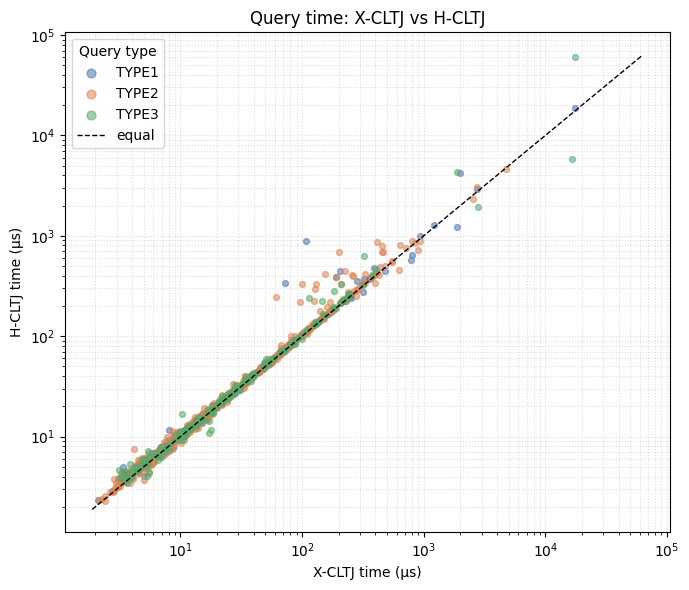

In [7]:
plot_time_scatter(df);

## CDF de speedup por tipo

`speedup = t_xcltj / t_hcltj`.  
Speedup > 1 → H-CLTJ más rápido. Línea roja = igualdad.

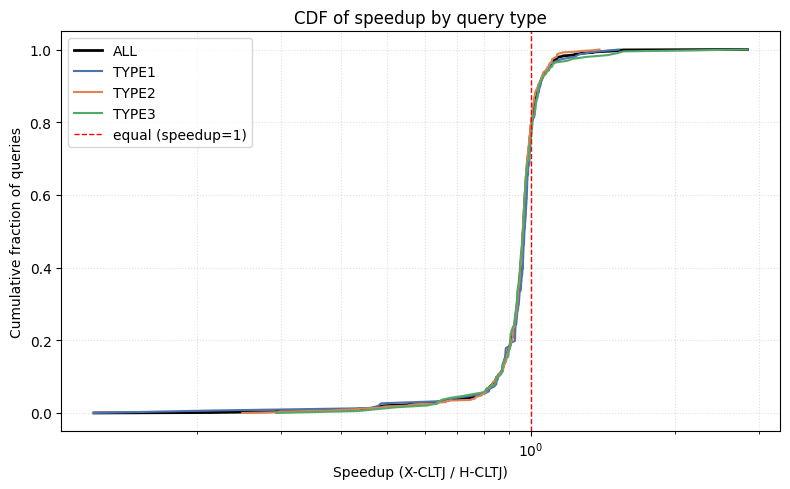

In [8]:
plot_speedup_cdf(df);

## Mediana de tiempos por tipo

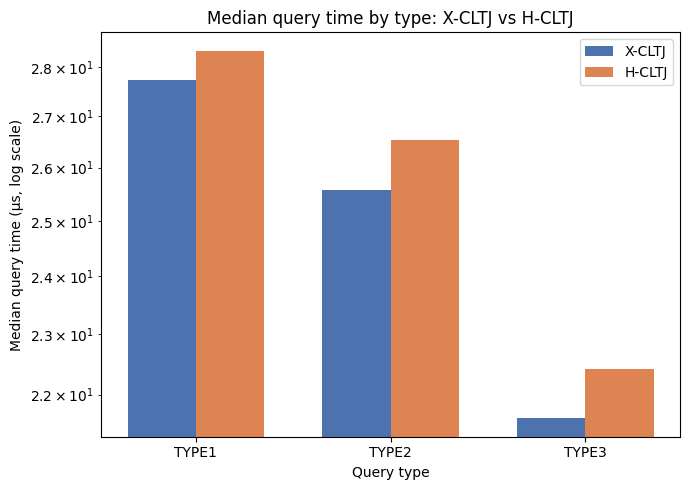

In [9]:
by_type = summary_by_type(df)
plot_median_by_type(by_type);

## Distribución de speedup por tipo (boxplot)

/Users/pabloskewes/FCFM/Magister/cltj/analysis/query_bench/plot.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


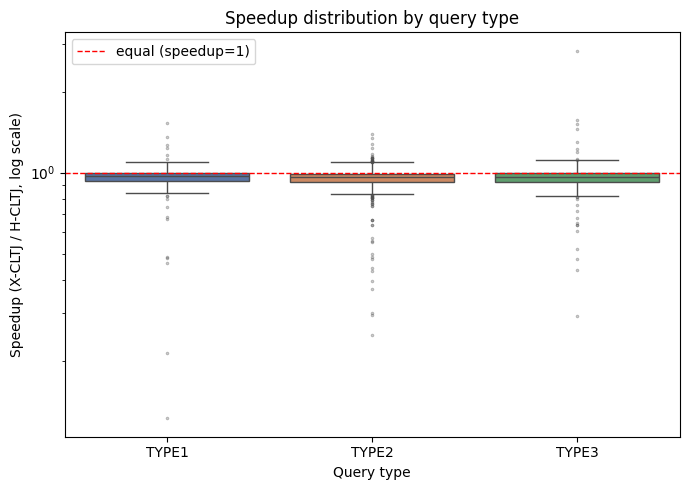

In [10]:
plot_speedup_boxplot(df);